<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/PCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#same as Yuwei's code

from google.colab import drive
drive.mount('/content/drive')
import os

import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
import gc
p_path = "/content/drive/My Drive/Campbell A data/preprocess_data.parquet"
LOCAL_PATH = '/content/df_processed.parquet'

# preprocess and saved to disk
if not os.path.exists(LOCAL_PATH):
    df = pd.read_parquet(p_path)

    # preprocess
    id_cols    = ['DATE', 'permno']
    float_cols = [c for c in df.columns if c not in id_cols]
    df[float_cols] = df[float_cols].astype(np.float32)

    # generate dummy variables
    sic_df        = pd.get_dummies(df['sic2'], prefix='sic')
    sic_cols_list = sic_df.columns.tolist()
    df            = pd.concat([df, sic_df], axis=1)

    # saved to disk
    df.to_parquet(LOCAL_PATH, index=False)
    print(f"finished preprocessing, saved to local disk")

# skip preprocess
else:
    df            = pd.read_parquet(LOCAL_PATH)
    sic_cols_list = [c for c in df.columns if c.startswith('sic_')]
    print(f"read from local disk, skip preprocessing")

print(f"df shape: {df.shape}")
def generate_920_features(df, char_cols, macro_cols, sic_cols):

    X_char = df[char_cols].to_numpy(dtype=np.float32, copy=False)
    X_macro = df[macro_cols].to_numpy(dtype=np.float32, copy=False)
    X_sic = df[sic_cols].to_numpy(dtype=np.float32, copy=False)

    # generate interaction (N x 752)

    X_inter = (X_char[:, :, np.newaxis] * X_macro[:, np.newaxis, :]).reshape(len(df), -1)

    # features (94) + interaction (752) + industry (74)
    X_920 = np.hstack([X_char, X_inter, X_sic])

    return X_920
macro=['tbl','d/p','e/p','b/m','tms','dfy','ntis','svar']
features=list(df.columns)[2:96]

def calc_oos_r2(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    denom = np.sum(actual ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((actual - predicted) ** 2) / denom

Mounted at /content/drive
finished preprocessing, saved to local disk
df shape: (3712808, 183)


In [3]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

def select_n_components_pcr(X_train, y_train, X_val, y_val,
                            max_components=10, prev_best_n=None):

    max_components = min(max_components, X_train.shape[1], X_train.shape[0] - 1)

    if prev_best_n is None:
        search_range = range(1, max_components + 1)
    else:
        lo = max(1, prev_best_n - 1)
        hi = min(max_components, prev_best_n + 1)
        search_range = range(lo, hi + 1)

    best_r2, best_n = -np.inf, 1
    for n in search_range:
        pcr = Pipeline([
            ('pca', PCA(n_components=n)),
            ('reg', LinearRegression())
        ])
        pcr.fit(X_train, y_train)
        r2 = calc_oos_r2(y_val, pcr.predict(X_val).ravel())
        if r2 > best_r2:
            best_r2, best_n = r2, n

    return best_n

In [4]:
import warnings
import time
import gc
import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler

start_test_year = 1987
end_test_year   = 2016
VAL_YEARS       = 12
MAX_COMPONENTS  = 10
all_preds   = []
prev_best_n = None
dates_all   = df['DATE'].values.copy()
y_all       = df['exret_lead1'].to_numpy(dtype=np.float32, copy=False)

del df
gc.collect()

needed_cols = features + macro + sic_cols_list + ['DATE', 'permno', 'exret_lead1', 'mvel1']
needed_cols = list(dict.fromkeys(needed_cols))

for year in range(start_test_year, end_test_year + 1):
    print(f"\n--- cope with {year} year ---")
    t0 = time.time()

    # split
    train_mask = (dates_all >= pd.Timestamp(1957, 3, 1)) & \
                 (dates_all <= pd.Timestamp(year - 13, 12, 31))
    val_mask   = (dates_all >= pd.Timestamp(year - 12, 1, 1)) & \
                 (dates_all <= pd.Timestamp(year - 1, 12, 31))
    test_mask  = (dates_all >= pd.Timestamp(year, 1, 1)) & \
                 (dates_all <= pd.Timestamp(year, 12, 31))

    df_year  = pq.read_table(LOCAL_PATH, columns=needed_cols).to_pandas()
    df_train = df_year[train_mask].reset_index(drop=True)
    df_val   = df_year[val_mask].reset_index(drop=True)
    df_test  = df_year[test_mask].reset_index(drop=True)
    del df_year
    gc.collect()

    X_train = generate_920_features(df_train, features, macro, sic_cols_list)
    y_train = y_all[train_mask]
    X_val   = generate_920_features(df_val,   features, macro, sic_cols_list)
    y_val   = y_all[val_mask]
    X_test  = generate_920_features(df_test,  features, macro, sic_cols_list)
    del df_train, df_val
    gc.collect()

    t1 = time.time()
    print(f'  feature construction used: {t1-t0:.1f}s  '
          f'| train rows: {len(X_train):,}  val rows: {len(X_val):,}')

    # parameter selection
    scaler_sel = StandardScaler()
    X_train_s  = scaler_sel.fit_transform(X_train)
    X_val_s    = scaler_sel.transform(X_val)

    best_n = select_n_components_pcr(
        X_train_s, y_train, X_val_s, y_val,
        max_components=MAX_COMPONENTS,
        prev_best_n=prev_best_n,
    )
    del X_train_s, X_val_s, scaler_sel
    gc.collect()
    print(f"  best_n={best_n}  select parameter used: {time.time()-t1:.1f}s")

    # train
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])
    del X_train, X_val, y_train, y_val
    gc.collect()

    scaler_final = StandardScaler()
    X_trainval_s = scaler_final.fit_transform(X_trainval)
    X_test_s     = scaler_final.transform(X_test)
    del X_trainval, X_test
    gc.collect()

    t2 = time.time()

    # Using the PCR Pipeline
    final_model = Pipeline([
        ('pca', PCA(n_components=best_n)),
        ('reg', LinearRegression())
    ])

    final_model.fit(X_trainval_s, y_trainval)
    del X_trainval_s, y_trainval
    gc.collect()
    print(f"  train used: {time.time()-t2:.1f}s  |  total: {time.time()-t0:.1f}s")

    # predict
    res = df_test[['DATE', 'permno', 'exret_lead1', 'mvel1']].copy().reset_index(drop=True)
    res['y_pred'] = final_model.predict(X_test_s).ravel()
    del X_test_s, final_model, df_test, scaler_final
    gc.collect()

    all_preds.append(res)
    prev_best_n = best_n



--- cope with 1987 year ---
  feature construction used: 5.5s  | train rows: 472,278  val rows: 764,497
  best_n=5  select parameter used: 35.2s
  train used: 4.4s  |  total: 61.2s

--- cope with 1988 year ---
  feature construction used: 5.7s  | train rows: 530,435  val rows: 788,744
  best_n=5  select parameter used: 18.7s
  train used: 4.4s  |  total: 46.0s

--- cope with 1989 year ---
  feature construction used: 6.0s  | train rows: 588,534  val rows: 814,060
  best_n=6  select parameter used: 18.6s
  train used: 5.0s  |  total: 47.9s

--- cope with 1990 year ---
  feature construction used: 6.2s  | train rows: 647,363  val rows: 836,447
  best_n=7  select parameter used: 20.0s
  train used: 5.2s  |  total: 50.7s

--- cope with 1991 year ---
  feature construction used: 6.4s  | train rows: 704,916  val rows: 859,101
  best_n=8  select parameter used: 21.7s
  train used: 7.0s  |  total: 55.3s

--- cope with 1992 year ---
  feature construction used: 6.7s  | train rows: 761,970  val

In [5]:
results = pd.concat(all_preds, ignore_index=True)

r2_all = calc_oos_r2(results['exret_lead1'], results['y_pred'])

top1000 = (
    results
    .sort_values(['DATE', 'mvel1'], ascending=[True, False])
    .groupby('DATE', sort=False).head(1000)
)
r2_top = calc_oos_r2(top1000['exret_lead1'], top1000['y_pred'])

bot1000 = (
    results
    .sort_values(['DATE', 'mvel1'], ascending=[True, True])
    .groupby('DATE', sort=False).head(1000)
)
r2_bot = calc_oos_r2(bot1000['exret_lead1'], bot1000['y_pred'])

print(f"\n{'='*45}")
print(f"  {'Subsample':<25}  {'OOS R2':>10}")
print(f"{'-'*45}")
print(f"  {'All stocks':<25}  {r2_all*100:>+10.4f}%")
print(f"  {'Top 1000 (largest)':<25}  {r2_top*100:>+10.4f}%")
print(f"  {'Bottom 1000 (smallest)':<25}  {r2_bot*100:>+10.4f}%")
print(f"{'='*45}")

export_path = '/content/drive/MyDrive/pcr_predictions.parquet'
results.to_parquet(export_path, index=False)


  Subsample                      OOS R2
---------------------------------------------
  All stocks                    +0.1738%
  Top 1000 (largest)            +0.2664%
  Bottom 1000 (smallest)        +0.2218%


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_parquet("/content/drive/MyDrive/pcr_predictions.parquet")

# clean
results = results[['DATE', 'permno', 'exret_lead1', 'mvel1', 'y_pred']].dropna().copy()
results['DATE'] = pd.to_datetime(results['DATE'])

# convert log market equity to positive weights
results['me'] = np.exp(results['mvel1'])

def assign_deciles(x):
    r = x.rank(method='first')
    return pd.qcut(r, 10, labels=False) + 1

# assign monthly prediction deciles
results['decile'] = results.groupby('DATE')['y_pred'].transform(assign_deciles)

# equal-weighted decile returns
ew_deciles = (
    results.groupby(['DATE', 'decile'])['exret_lead1']
    .mean()
    .reset_index(name='ret_ew')
)

# value-weighted decile returns
vw_deciles = (
    results.groupby(['DATE', 'decile'])
    .apply(lambda g: np.average(g['exret_lead1'], weights=g['me']))
    .reset_index(name='ret_vw')
)

# wide format
ew_wide = ew_deciles.pivot(index='DATE', columns='decile', values='ret_ew').sort_index()
vw_wide = vw_deciles.pivot(index='DATE', columns='decile', values='ret_vw').sort_index()

# long-short 10-1
ew_wide['LS_10_1'] = ew_wide[10] - ew_wide[1]
vw_wide['LS_10_1'] = vw_wide[10] - vw_wide[1]

def perf_stats(ret):
    ret = pd.Series(ret).dropna()
    avg_m = ret.mean()
    std_m = ret.std(ddof=1)
    sharpe_ann = (avg_m / std_m) * np.sqrt(12) if std_m > 0 else np.nan
    cum_ret = (1 + ret).prod() - 1
    return {
        'avg_monthly_return': avg_m,
        'std_monthly_return': std_m,
        'annualized_sharpe': sharpe_ann,
        'total_cumulative_return': cum_ret
    }

print("Equal-weighted LS(10-1):")
print(perf_stats(ew_wide['LS_10_1']))

print("\nValue-weighted LS(10-1):")
print(perf_stats(vw_wide['LS_10_1']))

Equal-weighted LS(10-1):
{'avg_monthly_return': np.float32(0.015650354), 'std_monthly_return': 0.04323887079954147, 'annualized_sharpe': np.float64(1.2538352277919103), 'total_cumulative_return': np.float32(192.4705)}

Value-weighted LS(10-1):
{'avg_monthly_return': np.float32(0.012977245), 'std_monthly_return': 0.040472786873579025, 'annualized_sharpe': np.float64(1.1107338699895775), 'total_cumulative_return': np.float32(77.03491)}


/tmp/ipykernel_820/3578899943.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['exret_lead1'], weights=g['me']))


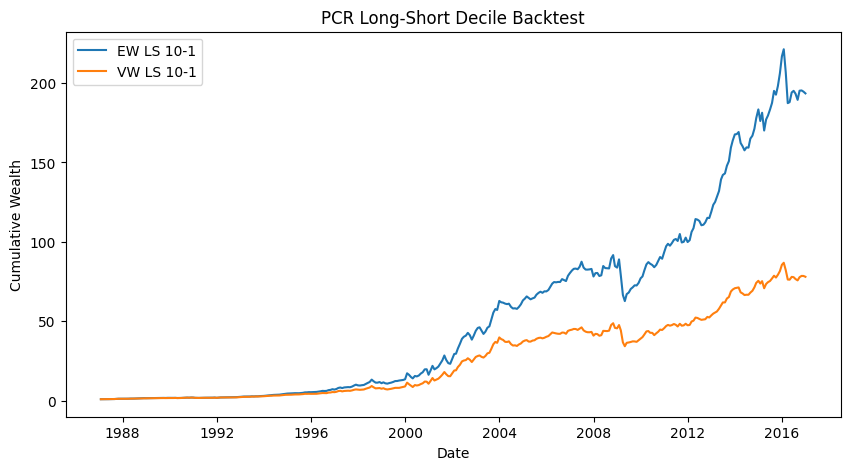

In [9]:
plt.figure(figsize=(10, 5))
plt.plot((1 + ew_wide['LS_10_1'].fillna(0)).cumprod(), label='EW LS 10-1')
plt.plot((1 + vw_wide['LS_10_1'].fillna(0)).cumprod(), label='VW LS 10-1')
plt.legend()
plt.title('PCR Long-Short Decile Backtest')
plt.ylabel('Cumulative Wealth')
plt.xlabel('Date')
plt.show()

In [10]:
ew_summary = ew_deciles.groupby('decile')['ret_ew'].agg(['mean', 'std'])
ew_summary['SR_ann'] = ew_summary['mean'] / ew_summary['std'] * np.sqrt(12)

vw_summary = vw_deciles.groupby('decile')['ret_vw'].agg(['mean', 'std'])
vw_summary['SR_ann'] = vw_summary['mean'] / vw_summary['std'] * np.sqrt(12)

print("\nEqual-weighted deciles:")
print(ew_summary)

print("\nValue-weighted deciles:")
print(vw_summary)


Equal-weighted deciles:
            mean       std    SR_ann
decile                              
1      -0.000279  0.075496 -0.012813
2       0.004404  0.064237  0.237493
3       0.005800  0.061431  0.327056
4       0.005840  0.058461  0.346044
5       0.006194  0.052624  0.407745
6       0.007711  0.046194  0.578255
7       0.009016  0.041497  0.752613
8       0.010193  0.044750  0.789009
9       0.012411  0.052273  0.822506
10      0.015371  0.056007  0.950725

Value-weighted deciles:
            mean       std    SR_ann
decile                              
1       0.000657  0.069407  0.032804
2       0.004557  0.058444  0.270117
3       0.005872  0.055876  0.364072
4       0.006008  0.055228  0.376862
5       0.006629  0.049521  0.463724
6       0.007593  0.044060  0.596965
7       0.008635  0.041354  0.723373
8       0.009560  0.044357  0.746580
9       0.011258  0.050274  0.775720
10      0.013634  0.054316  0.869566


In [12]:
import numpy as np
import pandas as pd

# load
df = pd.read_parquet("/content/drive/MyDrive/pcr_predictions.parquet")

df = df[['DATE','permno','exret_lead1','mvel1','y_pred']].dropna().copy()
df['DATE'] = pd.to_datetime(df['DATE'])

# mvel1 is log ME
df['me'] = np.exp(df['mvel1'])

def oos_r2(y, yhat):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    return 1 - np.sum((y - yhat)**2) / np.sum(y**2)

r2 = oos_r2(df['exret_lead1'], df['y_pred'])
print(f"OOS R^2: {r2:.6f}")

def deciles(x):
    r = x.rank(method='first')
    return pd.qcut(r, 10, labels=False) + 1

df['decile'] = df.groupby('DATE')['y_pred'].transform(deciles)


# Portfolio returns
# equal-weight
ew = (
    df.groupby(['DATE','decile'])['exret_lead1']
      .mean()
      .reset_index(name='ret')
)

# value-weight
vw = (
    df.groupby(['DATE','decile'])
      .apply(lambda g: np.average(g['exret_lead1'], weights=g['me']))
      .reset_index(name='ret')
)

# predicted returns
pred = (
    df.groupby(['DATE','decile'])
      .apply(lambda g: np.average(g['y_pred'], weights=g['me']))
      .reset_index(name='pred')
)

vw = vw.merge(pred, on=['DATE','decile'])

# LS portfolio
vw_wide = vw.pivot(index='DATE', columns='decile', values='ret').sort_index()
ew_wide = ew.pivot(index='DATE', columns='decile', values='ret').sort_index()

vw_wide['LS'] = vw_wide[10] - vw_wide[1]
ew_wide['LS'] = ew_wide[10] - ew_wide[1]

def perf(ret):
    ret = ret.dropna()
    mean = ret.mean()
    std = ret.std(ddof=1)
    sharpe = (mean / std) * np.sqrt(12)
    return mean, sharpe

vw_mean, vw_sr = perf(vw_wide['LS'])
ew_mean, ew_sr = perf(ew_wide['LS'])

print("\n=== Long-Short 10–1 ===")
print(f"VW mean: {vw_mean:.4f}   VW Sharpe: {vw_sr:.2f}")
print(f"EW mean: {ew_mean:.4f}   EW Sharpe: {ew_sr:.2f}")

summary = (
    vw.groupby('decile')
      .agg(
          Pred=('pred','mean'),
          Realized=('ret','mean'),
          Std=('ret','std')
      )
      .reset_index()
)

summary['Sharpe'] = summary['Realized'] / summary['Std'] * np.sqrt(12)

print("\n=== Decile Table (Value-Weighted) ===")
print(summary.round(4))

OOS R^2: 0.001738


/tmp/ipykernel_820/91820523.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['exret_lead1'], weights=g['me']))



=== Long-Short 10–1 ===
VW mean: 0.0130   VW Sharpe: 1.11
EW mean: 0.0157   EW Sharpe: 1.25

=== Decile Table (Value-Weighted) ===
   decile    Pred  Realized     Std  Sharpe
0       1 -0.0002    0.0007  0.0694  0.0328
1       2  0.0029    0.0046  0.0584  0.2701
2       3  0.0045    0.0059  0.0559  0.3641
3       4  0.0056    0.0060  0.0552  0.3769
4       5  0.0065    0.0066  0.0495  0.4637
5       6  0.0073    0.0076  0.0441  0.5970
6       7  0.0080    0.0086  0.0414  0.7234
7       8  0.0090    0.0096  0.0444  0.7466
8       9  0.0106    0.0113  0.0503  0.7757
9      10  0.0138    0.0136  0.0543  0.8696


/tmp/ipykernel_820/91820523.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['y_pred'], weights=g['me']))
